In [1]:
import pandas as pd
import geopandas as geopd
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import math

<Axes: >

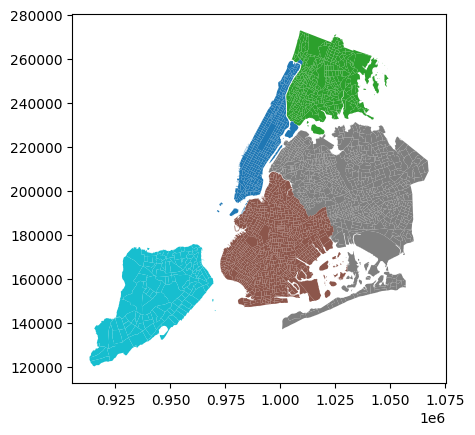

In [2]:
tractData = geopd.GeoDataFrame.from_file('./nycCensusTracts/nyct2020.dbf')
tractData.plot(column="BoroCode")

In [3]:
tractData['GEOID'] = tractData['GEOID'].astype(np.int64)
tractData

,CTLabel,BoroCode,BoroName,CT2020,BoroCT2020,CDEligibil,NTAName,NTA2020,CDTA2020,CDTANAME,GEOID,PUMA,Shape_Leng,Shape_Area,geometry
0,1,1,Manhattan,000100,1000100,I,The Battery-Governors Island-Ellis Island-Libe...,MN0191,MN01,MN01 Financial District-Tribeca (CD 1 Equivalent),36061000100,4121,10833.043929,1.843005e+06,"MULTIPOLYGON (((972081.788 190733.467, 972184...."
1,14.01,1,Manhattan,001401,1001401,I,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061001401,4103,5075.332000,1.006117e+06,"POLYGON ((987475.016 200297.218, 987705.443 20..."
2,14.02,1,Manhattan,001402,1001402,E,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061001402,4103,4459.156019,1.226206e+06,"POLYGON ((988387.669 201258.312, 988621.002 20..."
3,18,1,Manhattan,001800,1001800,I,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061001800,4103,6391.921174,2.399277e+06,"POLYGON ((987062.275 201781.687, 987099.571 20..."
4,22.01,1,Manhattan,002201,1002201,E,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061002201,4103,5779.062608,1.740174e+06,"POLYGON ((990139.804 201568.505, 990129.867 20..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2320,86,3,Brooklyn,008600,3008600,I,Sunset Park (Central),BK0703,BK07,BK07 Sunset Park-Windsor Terrace (CD 7 Approxi...,36047008600,4307,4685.245254,1.221917e+06,"POLYGON ((984066.247 175173.496, 983903.495 17..."
2321,92.01,3,Brooklyn,009201,3009201,E,Sunset Park (Central),BK0703,BK07,BK07 Sunset Park-Windsor Terrace (CD 7 Approxi...,36047009201,4307,3120.202586,6.086624e+05,"POLYGON ((984675.754 174689.613, 984514.261 17..."
2322,423,3,Brooklyn,042300,3042300,E,Bushwick (West),BK0401,BK04,BK04 Bushwick (CD 4 Equivalent),36047042300,4304,5572.234952,1.961468e+06,"POLYGON ((1004535.996 194799.903, 1004745.48 1..."
2323,391,3,Brooklyn,039100,3039100,E,Bushwick (West),BK0401,BK04,BK04 Bushwick (CD 4 Equivalent),36047039100,4304,6244.833441,1.788881e+06,"POLYGON ((1003515.745 193865.686, 1003587.174 ..."


In [4]:
censusData = pd.read_csv('./datasets/nyc_census_tracts.csv')
censusData

,CensusTract,County,Borough,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,36005000100,Bronx,Bronx,7703,7133,570,29.9,6.1,60.9,0.2,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
1,36005000200,Bronx,Bronx,5403,2659,2744,75.8,2.3,16.0,0.0,...,2.9,0.0,0.0,43.0,2308,80.8,16.2,2.9,0.0,7.7
2,36005000400,Bronx,Bronx,5915,2896,3019,62.7,3.6,30.7,0.0,...,1.4,0.5,2.1,45.0,2675,71.7,25.3,2.5,0.6,9.5
3,36005001600,Bronx,Bronx,5879,2558,3321,65.1,1.6,32.4,0.0,...,8.6,1.6,1.7,38.8,2120,75.0,21.3,3.8,0.0,8.7
4,36005001900,Bronx,Bronx,2591,1206,1385,55.4,9.0,29.0,0.0,...,3.0,2.4,6.2,45.4,1083,76.8,15.5,7.7,0.0,19.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2162,36085030302,Richmond,Staten Island,6279,3093,3186,35.8,28.7,17.6,0.0,...,0.9,0.0,1.3,46.6,2668,74.4,22.5,3.2,0.0,6.2
2163,36085031901,Richmond,Staten Island,2550,953,1597,27.1,6.2,60.4,0.0,...,9.5,0.0,0.0,38.2,710,73.8,21.8,4.4,0.0,13.8
2164,36085031902,Richmond,Staten Island,4611,2043,2568,20.9,14.7,61.9,0.0,...,0.5,0.0,2.7,40.9,1308,84.7,12.6,2.7,0.0,9.4
2165,36085032300,Richmond,Staten Island,1131,597,534,45.5,24.0,29.7,0.0,...,4.9,0.0,0.0,52.5,534,65.0,31.1,3.9,0.0,10.7


In [5]:
df = pd.merge(tractData, censusData, how='inner', left_on='GEOID', right_on='CensusTract')
df = df[df['TotalPop'] != 0]
numTracts = len(df)
df

,CTLabel,BoroCode,BoroName,CT2020,BoroCT2020,CDEligibil,NTAName,NTA2020,CDTA2020,CDTANAME,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
1,14.01,1,Manhattan,001401,1001401,I,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),...,15.7,10.4,8.2,29.0,1734,77.6,11.3,10.1,1.0,1.8
2,14.02,1,Manhattan,001402,1001402,E,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),...,12.9,4.9,7.6,32.8,1470,76.8,9.5,13.7,0.0,5.2
3,18,1,Manhattan,001800,1001800,I,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),...,22.5,4.9,11.3,29.8,4951,91.2,2.9,5.4,0.6,4.2
4,22.01,1,Manhattan,002201,1002201,E,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),...,17.1,2.1,1.7,36.4,3016,83.1,9.0,7.9,0.0,13.0
5,26.01,1,Manhattan,002601,1002601,E,East Village,MN0303,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),...,25.3,3.5,1.5,33.4,1952,78.7,17.8,3.5,0.0,8.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2027,327,3,Brooklyn,032700,3032700,E,Prospect Lefferts Gardens-Wingate,BK0902,BK09,BK09 Crown Heights (South) (CD 9 Approximation),...,5.5,4.0,2.0,43.7,1392,74.1,19.0,6.9,0.0,11.5
2029,47,3,Brooklyn,004700,3004700,I,Carroll Gardens-Cobble Hill-Gowanus-Red Hook,BK0601,BK06,BK06 Park Slope-Carroll Gardens (CD 6 Approxim...,...,5.5,6.7,4.5,37.6,1038,78.0,13.3,8.7,0.0,12.2
2031,423,3,Brooklyn,042300,3042300,E,Bushwick (West),BK0401,BK04,BK04 Bushwick (CD 4 Equivalent),...,9.9,3.8,5.8,37.7,2442,85.3,8.6,6.1,0.0,12.8
2032,391,3,Brooklyn,039100,3039100,E,Bushwick (West),BK0401,BK04,BK04 Bushwick (CD 4 Equivalent),...,9.6,0.9,4.7,36.8,1376,82.8,11.8,5.4,0.0,18.0


In [6]:
numTracts

1998

In [7]:
df.columns

Index(['CTLabel', 'BoroCode', 'BoroName', 'CT2020', 'BoroCT2020', 'CDEligibil',
       'NTAName', 'NTA2020', 'CDTA2020', 'CDTANAME', 'GEOID', 'PUMA',
       'Shape_Leng', 'Shape_Area', 'geometry', 'CensusTract', 'County',
       'Borough', 'TotalPop', 'Men', 'Women', 'Hispanic', 'White', 'Black',
       'Native', 'Asian', 'Citizen', 'Income', 'IncomeErr', 'IncomePerCap',
       'IncomePerCapErr', 'Poverty', 'ChildPoverty', 'Professional', 'Service',
       'Office', 'Construction', 'Production', 'Drive', 'Carpool', 'Transit',
       'Walk', 'OtherTransp', 'WorkAtHome', 'MeanCommute', 'Employed',
       'PrivateWork', 'PublicWork', 'SelfEmployed', 'FamilyWork',
       'Unemployment'],
      dtype='object')

Income per Capita Min:  2440.0
Income per Capita Max:  254204.0
Income per Capita Mean:  32067.24158714214
Income per Capita Std:  25354.42183724375


<Axes: >

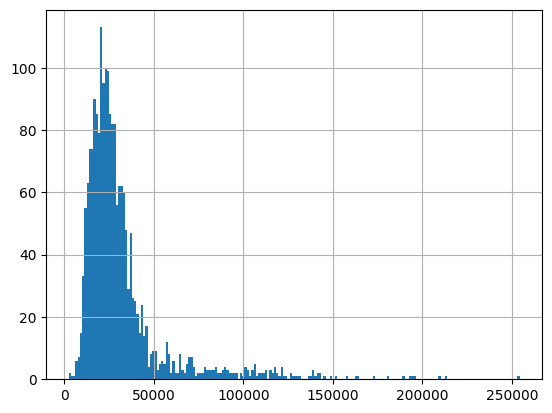

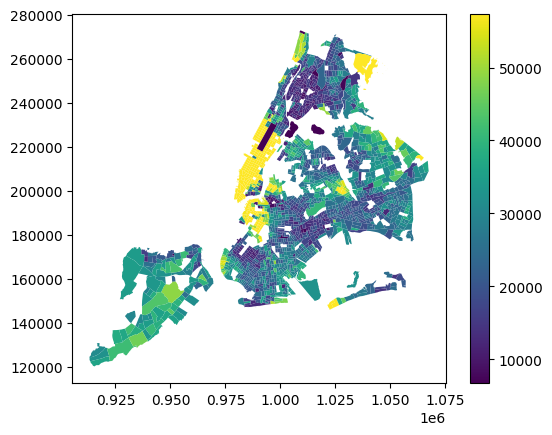

In [8]:
incomeMean = df['IncomePerCap'].mean()
incomeStd = df['IncomePerCap'].std()
print('Income per Capita Min: ', df['IncomePerCap'].min())
print('Income per Capita Max: ', df['IncomePerCap'].max())
print('Income per Capita Mean: ', df['IncomePerCap'].mean())
print('Income per Capita Std: ', df['IncomePerCap'].std())
df['IncomePerCap'].hist(bins=200)
df.plot(vmin=incomeMean-incomeStd, vmax=incomeMean+incomeStd, column='IncomePerCap', legend=True)

Population Min:  4
Population Max:  16231
Population Mean:  3813.9494494494493
Population Std:  1978.3534895821347


<Axes: >

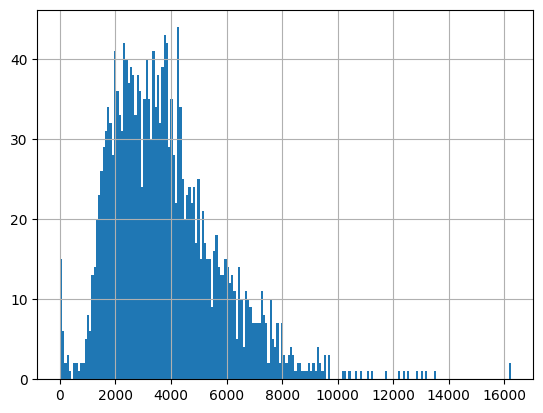

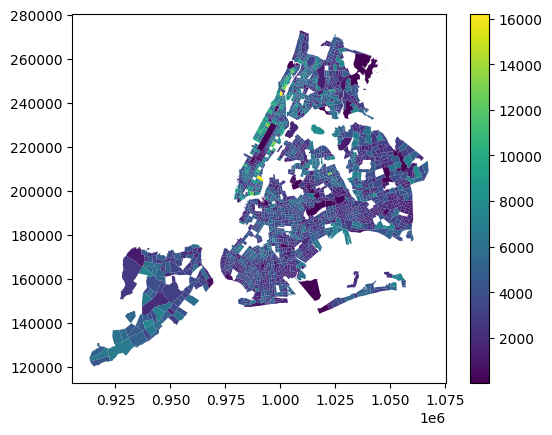

In [9]:
popMean = df['TotalPop'].mean()
popStd = df['TotalPop'].std()
print('Population Min: ', df['TotalPop'].min())
print('Population Max: ', df['TotalPop'].max())
print('Population Mean: ', df['TotalPop'].mean())
print('Population Std: ', df['TotalPop'].std())
df['TotalPop'].hist(bins=200)
df.plot(column='TotalPop', legend=True)

In [10]:
nycCasesByDay = pd.read_csv('./datasets/nyc_cases_by_day.csv')
nycCasesByDay['CASE_COUNT'].sum()

np.int64(626569)

In [ ]:
nycCasesByDay[nycCasesByDay['']]

7620271


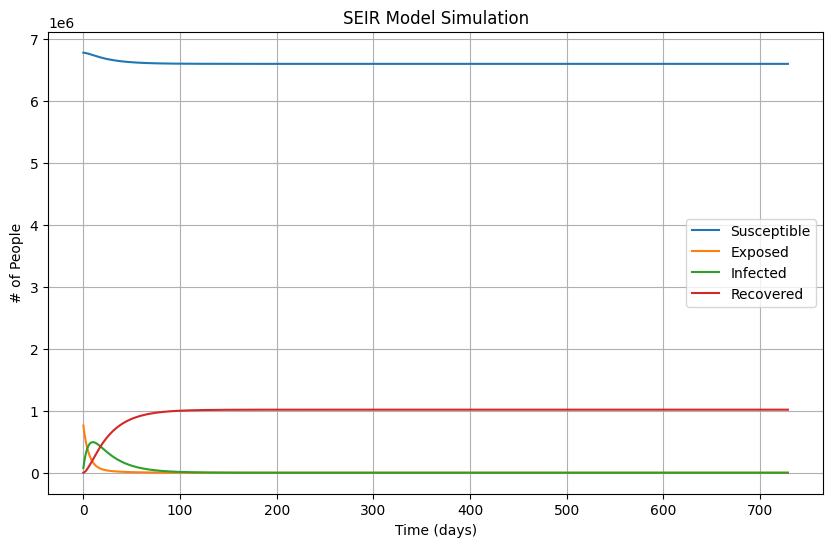

In [11]:
beta = 0.0115

covidIncubationPeriod = 6 #days
sigma = 1/covidIncubationPeriod

covidRecoveryPeriod = 17.5 #days
gamma = 1/covidRecoveryPeriod

def model(y, t, beta, sigma, gamma):
  S, E, I, R = y
  N = S + E + I + R
  dSdt = - beta * S * I / N
  dEdT = beta * S * I / N - sigma * E
  dIdt = sigma * E - gamma * I
  dRdt = gamma * I
  return dSdt, dEdT, dIdt, dRdt

print(df['TotalPop'].sum())
y0 = [df['TotalPop'].sum() * 0.89, df['TotalPop'].sum() * 0.1, df['TotalPop'].sum() * 0.01, 0]
t = np.arange(0, 730, 1)
sol = odeint(model, y0, t, args=(beta, sigma, gamma))
S, E, I, R = sol.T
plt.figure(figsize=(10, 6))
plt.plot(t, S, label='Susceptible')
plt.plot(t, E, label='Exposed')
plt.plot(t, I, label='Infected')
plt.plot(t, R, label='Recovered')
plt.xlabel('Time (days)')
plt.ylabel('# of People')
plt.title('SEIR Model Simulation')
plt.legend()
plt.grid(True)
plt.show()


In [12]:
def getBeta(t, income):
  betaMean = 0.0115
  betaStd = 0.005 if t < 225 else 0.01
  return max(betaStd * (incomeMean - income) / incomeStd + betaMean, 0.001)

In [13]:
def model(y, t, beta, sigma, gamma, income, vaccine_allocations, geoid):
  S, E, I, R, V = y
  N = S + E + I + R + V
  beta = getBeta(t, income)
  vaccination_rate = vaccine_allocations[729][geoid] / S if t > 729 else vaccine_allocations[math.ceil(t)][geoid] / S

  dSdt = - beta * S * I / N - vaccination_rate * S
  dEdT = beta * S * I / N - sigma * E
  dIdt = sigma * E - gamma * I
  dRdt = gamma * I
  dVdt = vaccination_rate * S
  return dSdt, dEdT, dIdt, dRdt, dVdt

def runSimulation(vaccine_allocations):
  simulationDf = df[['GEOID', 'geometry', 'TotalPop', 'IncomePerCap']]
  simulationDf['S'] = simulationDf['TotalPop'] * 0.9
  simulationDf['E'] = simulationDf['TotalPop'] * 0.1
  simulationDf['I'] = 0
  simulationDf['R'] = 0
  simulationDf['V'] = 0

  totals = [np.zeros(730) for i in range(5)]
  for index, row in simulationDf.iterrows():
    y0 = [row['S'], row['E'], row['I'], row['R'], row['V']]
    t = np.arange(0, 730, 1)
    sol = odeint(model, y0, t, args=(beta, sigma, gamma, row['IncomePerCap'], vaccine_allocations, row['GEOID']))
    S, E, I, R, V = sol.T
    simulationDf.loc[index, 'S'] = S[-1]
    simulationDf.loc[index, 'E'] = E[-1]
    simulationDf.loc[index, 'I'] = I[-1]
    simulationDf.loc[index, 'R'] = R[-1]
    simulationDf.loc[index, 'V'] = V[-1]

    if S[-1] < row['TotalPop'] and E[-1] < row['TotalPop'] and I[-1] < row['TotalPop'] and V[-1] < row['TotalPop'] and V[-1] < row['TotalPop']:
      totals[0] += S
      totals[1] += E
      totals[2] += I
      totals[3] += R
      totals[4] += V
    else:
      simulationDf = simulationDf[simulationDf['GEOID'] != row['GEOID']]

  simulationDf['percentV'] = simulationDf['V'] / simulationDf['TotalPop']
  simulationDf['percentIR'] = (simulationDf['I'] + simulationDf['R']) / simulationDf['TotalPop']

  simulationDf = simulationDf[simulationDf['percentV'] <= 1]
  simulationDf = simulationDf[simulationDf['percentIR'] <= 1]

  simulationDf.plot(column='percentV', vmin=simulationDf['percentV'].mean()-simulationDf['percentV'].std(), vmax=simulationDf['percentV'].mean()+simulationDf['percentV'].std(), legend=True)
  simulationDf.plot(column='percentIR', vmin=simulationDf['percentIR'].mean()-simulationDf['percentIR'].std(), vmax=simulationDf['percentIR'].mean()+simulationDf['percentIR'].std(), legend=True)
  simulationDf.plot(column='V', vmin=simulationDf['V'].mean()-simulationDf['V'].std(), vmax=simulationDf['V'].mean()+simulationDf['V'].std(), legend=True)
  simulationDf.plot(column='R', vmin=simulationDf['R'].mean()-simulationDf['R'].std(), vmax=simulationDf['R'].mean()+simulationDf['R'].std(), legend=True)


  print('Total Vaccinated', simulationDf['V'].sum())
  print('Total Infected & Recovered', simulationDf['I'].sum() + simulationDf['R'].sum())

  plt.figure(figsize=(10, 6))
  plt.plot(t, totals[0], label='Susceptible')
  plt.plot(t, totals[1], label='Exposed')
  plt.plot(t, totals[2], label='Infected')
  plt.plot(t, totals[3], label='Recovered')
  plt.plot(t, totals[4], label='Vaccinated')
  plt.xlabel('Time (days)')
  plt.ylabel('Proportion of Population')
  plt.title('SEIR Model Simulation')
  plt.legend()
  plt.grid(True)
  plt.show()

c:\Users\Nitin\AppData\Local\Programs\Python\Python311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Nitin\AppData\Local\Programs\Python\Python311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Nitin\AppData\Local\Programs\Python\Python311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is tryin

Total Vaccinated 485440.38456366723
Total Infected & Recovered 936680.9727235092


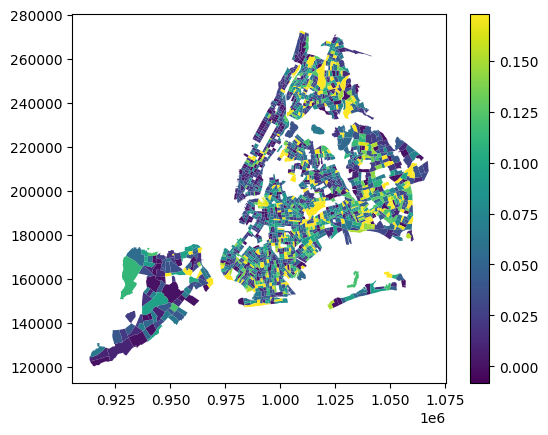

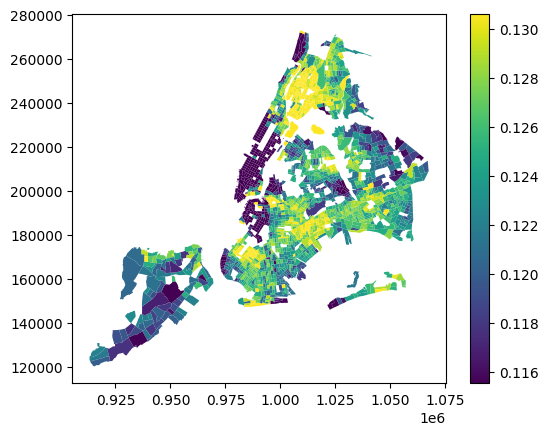

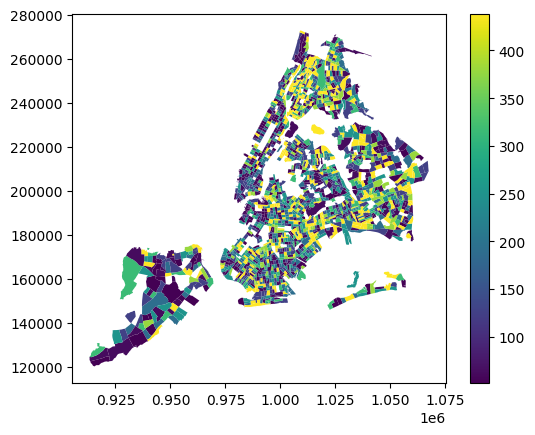

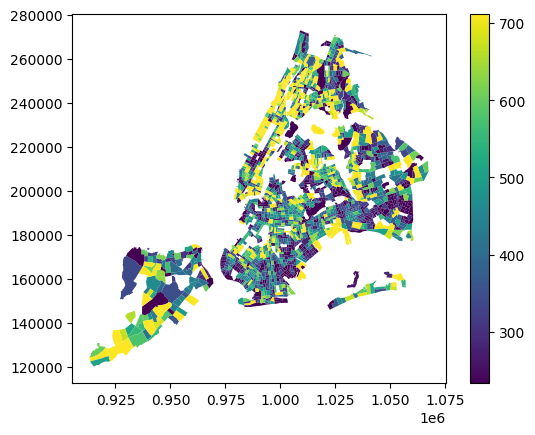

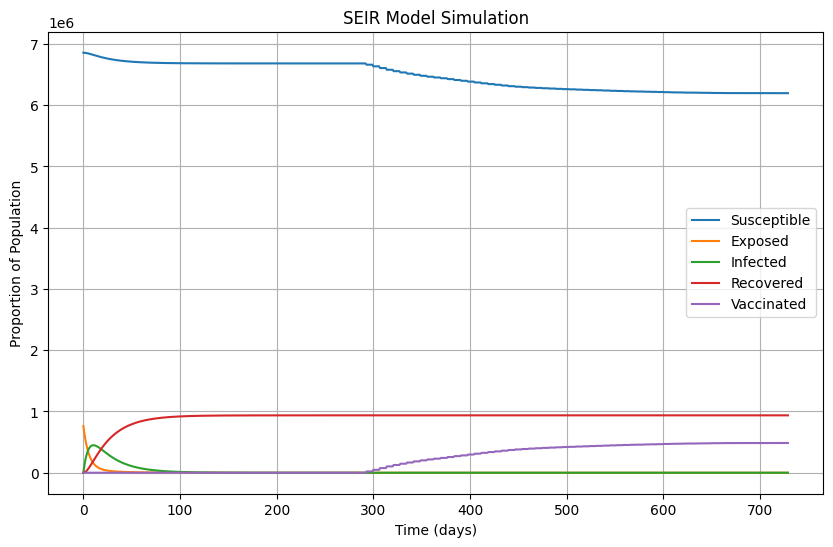

In [14]:
numVaccines = 8000000

uniformVaccineAllocations = {}
for t in range(730):
  numVaccinesPerWeek = 7 * numVaccines / (730 - 286)
  if t < 286 + 7 or (t - 286 - 7) % 7 != 0:
    uniformVaccineAllocations[t] = { geoid: 0 for geoid in df['GEOID'] }
    continue
  uniformVaccineAllocations[t] = { geoid: numVaccinesPerWeek / numTracts for geoid in df['GEOID'] }

runSimulation(uniformVaccineAllocations)

c:\Users\Nitin\AppData\Local\Programs\Python\Python311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Nitin\AppData\Local\Programs\Python\Python311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Nitin\AppData\Local\Programs\Python\Python311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is tryin

Total Vaccinated 485440.38456366723
Total Infected & Recovered 936680.9727235092


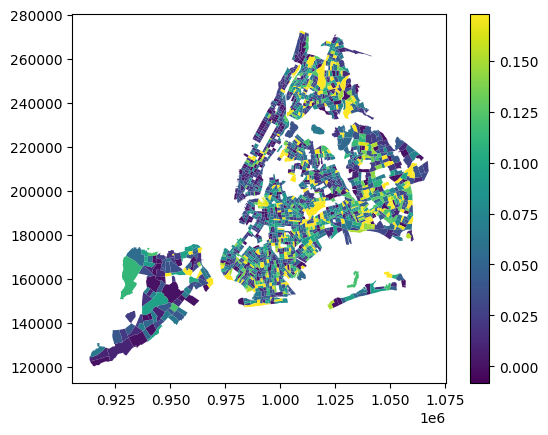

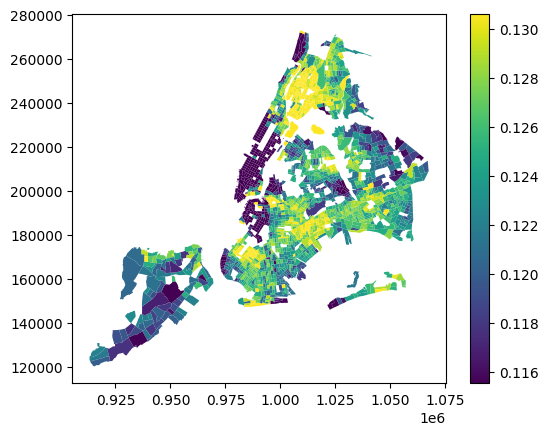

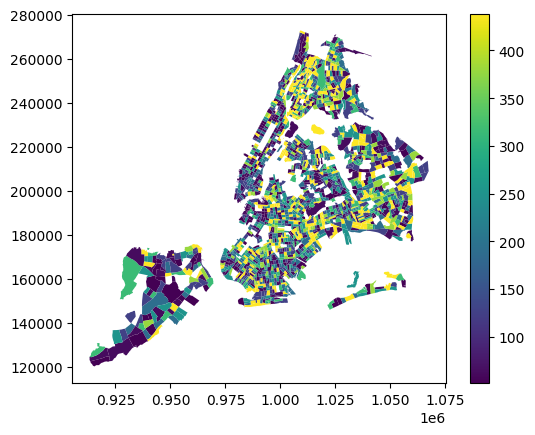

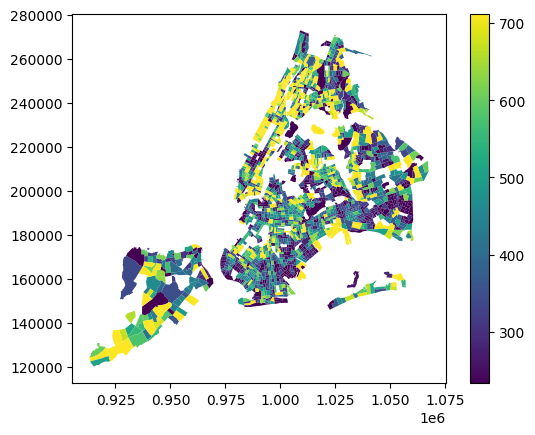

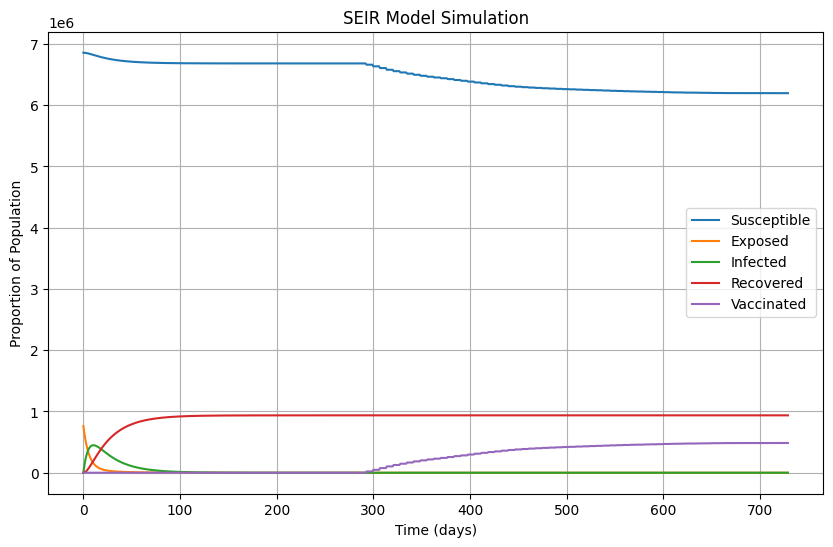

In [15]:
incomeBasedVaccineAllocations = {}
minIncomeZScore = (df['IncomePerCap'].min() - df['IncomePerCap'].median()) - df['IncomePerCap'].std()
df['VaccineAllotment'] = -(((df['IncomePerCap'] - df['IncomePerCap'].median()) / df['IncomePerCap'].std()) + minIncomeZScore)
df['VaccineAllotment'] = df['VaccineAllotment'] / df['VaccineAllotment'].sum()
df['TractPortions'] = df['IncomePerCap'] / df['IncomePerCap'].sum()
for t in range(730):                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
  numVaccinesPerWeek = 7 * numVaccines / (730 - 286)
  if t < 286 + 28 or (t - 286 - 28) % 7 != 0:
    incomeBasedVaccineAllocations[t] = { geoid: 0 for geoid in df['GEOID'] }
    continue
  incomeBasedVaccineAllocations[t] = {}
  for index, row in df.iterrows():
    geoid = row['GEOID']
    incomeBasedVaccineAllocations[t][geoid] = row['VaccineAllotment'] * numVaccinesPerWeek

runSimulation(uniformVaccineAllocations)

In [16]:
df = pd.read_csv('./datasets/COVID-19_Daily_Counts_of_Cases__Hospitalizations__and_Deaths.csv')

In [17]:
df

,date_of_interest,CASE_COUNT,PROBABLE_CASE_COUNT,HOSPITALIZED_COUNT,DEATH_COUNT,CASE_COUNT_7DAY_AVG,ALL_CASE_COUNT_7DAY_AVG,HOSP_COUNT_7DAY_AVG,DEATH_COUNT_7DAY_AVG,BX_CASE_COUNT,...,SI_CASE_COUNT,SI_PROBABLE_CASE_COUNT,SI_HOSPITALIZED_COUNT,SI_DEATH_COUNT,SI_PROBABLE_CASE_COUNT_7DAY_AVG,SI_CASE_COUNT_7DAY_AVG,SI_ALL_CASE_COUNT_7DAY_AVG,SI_HOSPITALIZED_COUNT_7DAY_AVG,SI_DEATH_COUNT_7DAY_AVG,INCOMPLETE
0,02/29/2020,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,03/01/2020,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,03/02/2020,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,03/03/2020,1,0,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,03/04/2020,5,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1804,02/06/2025,293,191,35,0,311,495,30,2,62,...,14,29,2,0,21,28,49,3,0,61030
1805,02/07/2025,302,154,29,2,309,493,31,2,63,...,39,13,1,0,21,31,51,3,0,61030
1806,02/08/2025,225,141,29,0,312,500,31,2,35,...,18,17,4,0,19,31,50,3,0,61030
1807,02/09/2025,169,105,6,0,310,494,28,2,20,...,22,11,2,0,19,30,49,3,0,61030
